#Load Libraries

In [256]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score

)

from sklearn.svm import SVR
from imblearn.over_sampling import SMOTE


#Load Dataset

In [195]:
df = pd.read_csv('/content/drive/MyDrive/ict_aiml/datasets/heart_disease.csv')


#EDA

In [196]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [197]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [198]:
df.shape

(1025, 14)

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [200]:
df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [201]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [202]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [203]:
#Identify numerical columns
numerical_columns = df.select_dtypes(include='number').columns
numerical_columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [204]:

df.select_dtypes(include='object').columns

# no categorical columns


Index([], dtype='object')

#Preprocessing

### Handle Missing Values

In [205]:
df.isna().sum().sum()
# No missing values found
# Missing-value imputation is not required

np.int64(0)

In [206]:
df.duplicated().sum()

np.int64(723)

In [207]:
df[df.duplicated()].head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1


In [208]:
# dataset contains repeated observations

# Outlier detection

In [209]:
numerical_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

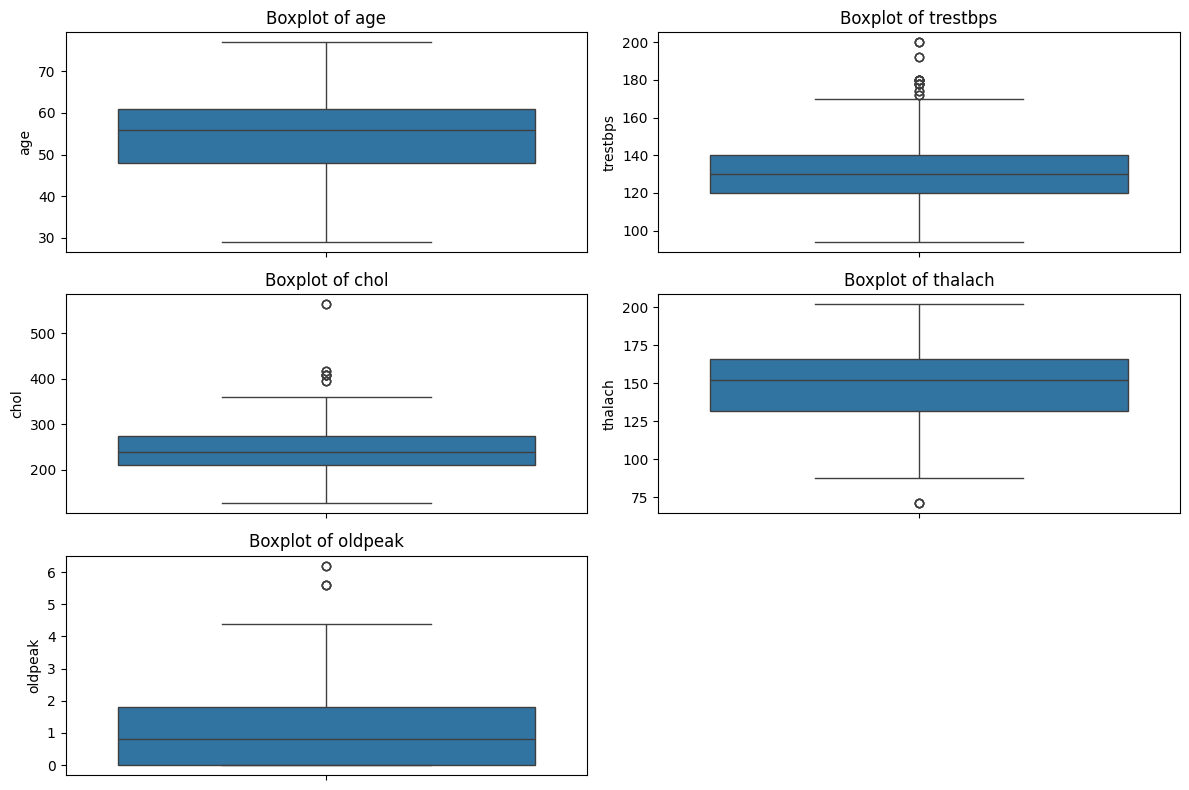

In [210]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(3, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

#### not handle outliers

In [211]:
# no encoding needed because there is no categorical columns

#Train Test Split Classification

In [212]:
X_class = df.drop('target', axis=1)
y_class = df['target']

In [213]:
X_class.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [214]:
y_class.head()

,target
0,0
1,0
2,0
3,0
4,0


In [215]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [216]:
print("Classification:")
print("X_train:", X_train_class.shape)
print("X_test:", X_test_class.shape)
print("y_train:", y_train_class.shape)
print("y_test:", y_test_class.shape)

Classification:
X_train: (820, 13)
X_test: (205, 13)
y_train: (820,)
y_test: (205,)


#Train Test Split Regression

In [217]:
X_reg = df.drop('chol', axis=1)
y_reg = df['chol']

In [218]:
X_reg.head()

,age,sex,cp,trestbps,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,1,1,106,0,1.9,1,3,2,0


In [219]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [220]:
print("Regression:")
print("X_train:", X_train_reg.shape)
print("X_test:", X_test_reg.shape)
print("y_train:", y_train_reg.shape)
print("y_test:", y_test_reg.shape)

Regression:
X_train: (820, 13)
X_test: (205, 13)
y_train: (820,)
y_test: (205,)


# Feature Selection


#### Classification Feature Selection

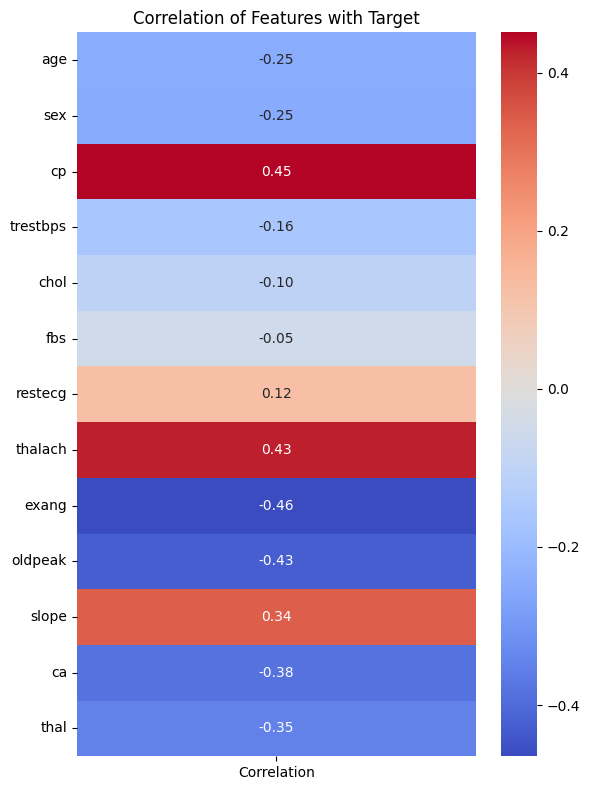

In [221]:
# Correlation of features with classification target

corr_class = X_train_class.corrwith(y_train_class)

plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_class.to_frame(name='Correlation'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation of Features with Target')
plt.tight_layout()
plt.show()

In [222]:
sel_col_class = corr_class[corr_class.abs() > 0.2].index.tolist()

print("Selected features:", sel_col_class)

Selected features: ['age', 'sex', 'cp', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [223]:
X_train_class = X_train_class[sel_col_class]
X_test_class = X_test_class[sel_col_class]

In [224]:
X_train_class.head()

,age,sex,cp,thalach,exang,oldpeak,slope,ca,thal
4,62,0,0,106,0,1.9,1,3,2
688,56,0,0,133,1,4.0,0,2,3
477,57,1,2,150,0,0.4,1,1,3
336,57,1,2,173,0,0.2,2,1,3
960,52,0,2,169,0,0.1,1,0,2


#### Regression Feature Selection

In [225]:
# Correlation of features with regression target

corr_reg = X_train_reg.corrwith(y_train_reg)

print(corr_reg)


age         0.238369
sex        -0.177799
cp         -0.104164
trestbps    0.153424
fbs         0.060880
restecg    -0.147512
thalach    -0.033765
exang       0.095113
oldpeak     0.027657
slope       0.004554
ca          0.076479
thal        0.098206
target     -0.132718
dtype: float64


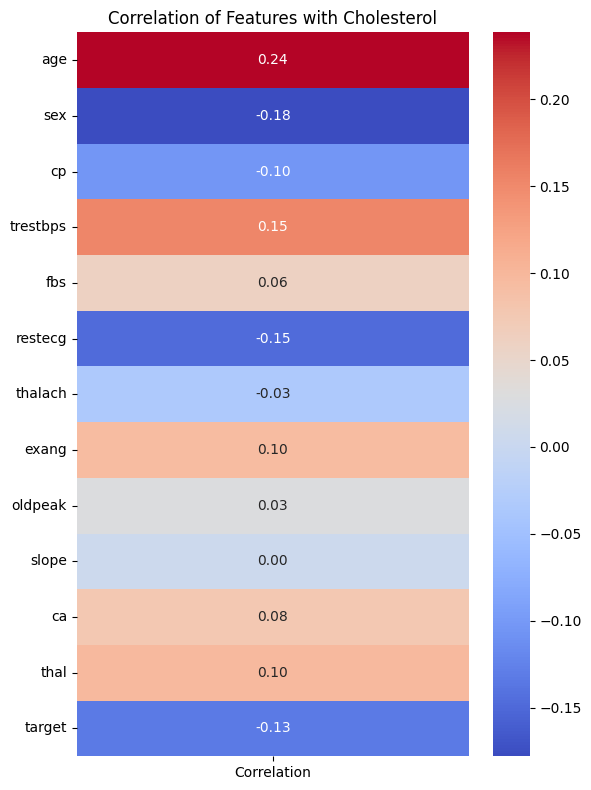

In [226]:
plt.figure(figsize=(6, 8))

sns.heatmap(
    corr_reg.to_frame(name='Correlation'),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation of Features with Cholesterol')
plt.tight_layout()
plt.show()

In [227]:
sel_col_reg = [
    'age',
    'sex',
    'trestbps',
    'fbs',
    'thalach'
]

In [228]:
X_train_reg = X_train_reg[sel_col_reg]
X_test_reg = X_test_reg[sel_col_reg]

In [229]:
X_train_reg.head()

,age,sex,trestbps,fbs,thalach
835,49,1,118,0,126
137,64,0,180,0,154
534,54,0,108,0,167
495,59,1,135,0,161
244,51,1,125,1,166


# Feature Scaling

In [230]:
#Classification scaling
numerical_cols_class = [
    'age',
    'thalach',
    'oldpeak'
]

In [231]:
scaler_class = StandardScaler()

In [232]:
X_train_class_scaled = X_train_class.copy()
X_test_class_scaled = X_test_class.copy()

X_train_class_scaled[numerical_cols_class] = scaler_class.fit_transform(
    X_train_class[numerical_cols_class]
)

X_test_class_scaled[numerical_cols_class] = scaler_class.transform(
    X_test_class[numerical_cols_class]
)

In [233]:
X_train_class_scaled.head()

,age,sex,cp,thalach,exang,oldpeak,slope,ca,thal
4,0.811626,0,0,-1.921155,0,0.696525,1,3,2
688,0.152247,0,0,-0.725362,1,2.475810,0,2,3
477,0.262144,1,2,0.027545,0,-0.574393,1,1,3
336,0.262144,1,2,1.046184,0,-0.743849,2,1,3
960,-0.287339,0,2,0.869030,0,-0.828577,1,0,2


In [234]:
X_train_class_scaled[numerical_cols_class].describe()

,age,thalach,oldpeak
count,8.200000e+02,8.200000e+02,8.200000e+02
mean,-2.426243e-16,1.148133e-16,3.574377e-17
std,1.000610e+00,1.000610e+00,1.000610e+00
min,-2.814960e+00,-3.471258e+00,-9.133044e-01
25%,-7.269256e-01,-7.253616e-01,-9.133044e-01
50%,1.522469e-01,1.161227e-01,-2.354815e-01
75%,7.017298e-01,6.918751e-01,6.117972e-01
max,2.460075e+00,2.330555e+00,4.339823e+00


###SMOTE

In [235]:
smote = SMOTE(random_state=42)

X_train_class_smote, y_train_class_smote = smote.fit_resample(
    X_train_class_scaled,
    y_train_class
)

In [236]:

print("Before SMOTE:")
print(y_train_class.value_counts())
print("\nAfter SMOTE:")
print(y_train_class_smote.value_counts())

Before SMOTE:
target
1    421
0    399
Name: count, dtype: int64

After SMOTE:
target
0    421
1    421
Name: count, dtype: int64


In [237]:
# Regression scaling
numerical_cols_reg = [
    'age',
    'trestbps',
    'thalach'
]

In [238]:
scaler_reg = StandardScaler()

In [239]:
X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_reg_scaled[numerical_cols_reg] = scaler_reg.fit_transform(
    X_train_reg[numerical_cols_reg]
)

X_test_reg_scaled[numerical_cols_reg] = scaler_reg.transform(
    X_test_reg[numerical_cols_reg]
)

In [240]:
X_train_reg_scaled.head()

,age,sex,trestbps,fbs,thalach
835,-0.585840,1,-0.779454,0,-1.019094
137,1.051477,0,2.741732,0,0.202882
534,-0.040068,0,-1.347387,0,0.770228
495,0.505705,1,0.186033,0,0.508376
244,-0.367531,1,-0.381900,1,0.726586


# Classification Model

In [241]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)

rf = RandomForestClassifier(n_estimators=100,random_state=42)

In [243]:
log_reg.fit(X_train_class_smote, y_train_class_smote)

knn.fit(X_train_class_smote, y_train_class_smote)

rf.fit(X_train_class_smote, y_train_class_smote)

RandomForestClassifier(random_state=42)

In [244]:
y_pred_lr = log_reg.predict(X_test_class_scaled)

y_pred_knn = knn.predict(X_test_class_scaled)

y_pred_rf = rf.predict(X_test_class_scaled)

In [245]:
models = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf
}


        LOGISTIC REGRESSION
Accuracy: 83.41%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.76      0.82       100
     Disease       0.80      0.90      0.85       105

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



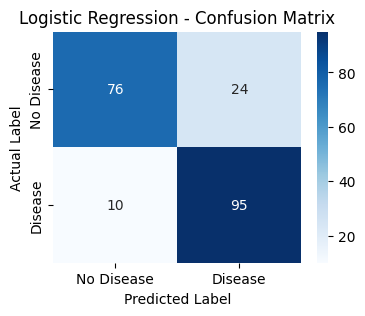



        KNN
Accuracy: 83.41%

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.81      0.83       100
     Disease       0.83      0.86      0.84       105

    accuracy                           0.83       205
   macro avg       0.83      0.83      0.83       205
weighted avg       0.83      0.83      0.83       205



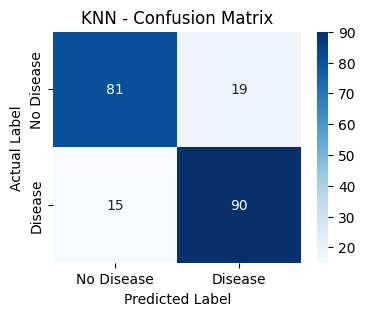



        RANDOM FOREST
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



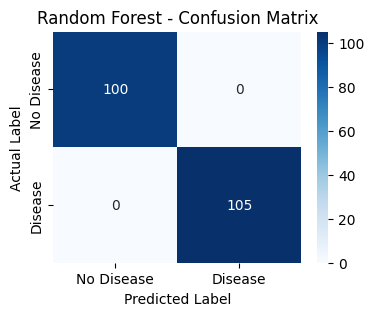

In [246]:
for name, y_pred in models.items():

    print("=" * 40)
    print(f"        {name.upper()}")
    print("=" * 40)

    acc = accuracy_score(y_test_class, y_pred)
    print(f"Accuracy: {acc * 100:.2f}%\n")

    print("Classification Report:")
    print(
        classification_report(
            y_test_class,
            y_pred,
            target_names=["No Disease", "Disease"]
        )
    )

    cm = confusion_matrix(y_test_class, y_pred)

    plt.figure(figsize=(4, 3))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

    print("\n")

# Model Regression

In [247]:
linear_reg = LinearRegression()

svm_reg = SVR()

rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [248]:
linear_reg.fit(X_train_reg_scaled, y_train_reg)

svm_reg.fit(X_train_reg_scaled, y_train_reg)

rf_reg.fit(X_train_reg_scaled, y_train_reg)

RandomForestRegressor(random_state=42)

In [249]:
y_pred_lr_reg = linear_reg.predict(X_test_reg_scaled)

y_pred_svm_reg = svm_reg.predict(X_test_reg_scaled)

y_pred_rf_reg = rf_reg.predict(X_test_reg_scaled)

In [252]:
# Linear Regression
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr_reg)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr_reg)
r2_lr = r2_score(y_test_reg, y_pred_lr_reg)

# SVM
mae_svm = mean_absolute_error(y_test_reg, y_pred_svm_reg)
mse_svm = mean_squared_error(y_test_reg, y_pred_svm_reg)
r2_svm = r2_score(y_test_reg, y_pred_svm_reg)

# Random Forest
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

In [253]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVM',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_svm,
        mae_rf
    ],
    'MSE': [
        mse_lr,
        mse_svm,
        mse_rf
    ],
    'R²': [
        r2_lr,
        r2_svm,
        r2_rf
    ]
})

regression_results

,Model,MAE,MSE,R²
0,Linear Regression,40.915224,3211.295099,0.061626
1,SVM,40.781788,3283.181334,0.040620
2,Random Forest,8.470488,289.172463,0.915501


In [257]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test_class, y_pred_lr),
        accuracy_score(y_test_class, y_pred_knn),
        accuracy_score(y_test_class, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test_class, y_pred_lr),
        precision_score(y_test_class, y_pred_knn),
        precision_score(y_test_class, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test_class, y_pred_lr),
        recall_score(y_test_class, y_pred_knn),
        recall_score(y_test_class, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test_class, y_pred_lr),
        f1_score(y_test_class, y_pred_knn),
        f1_score(y_test_class, y_pred_rf)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.834146,0.798319,0.904762,0.848214
1,KNN,0.834146,0.825688,0.857143,0.841121
2,Random Forest,1.000000,1.000000,1.000000,1.000000


# Classification :The models were compared using Accuracy, Precision, Recall, and F1 Score, with Recall as the main metric

#Regression: Random Forest performed the best, with an R² score of 0.9155 and the lowest MAE and MSE.